In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import random
from skimage.filters import threshold_sauvola, threshold_niblack
from joblib import Parallel, delayed
import json
from datetime import datetime
import IPython.display as display
from PIL import Image
import io
import time

%matplotlib inline

In [39]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from skimage.feature import hog

# Path to your training directory containing 'cat.X.jpg' and 'dog.X.jpg'
DATASET_DIR = r"C:\Users\PC-LAB1\img_processing_lab\day05\data\dogs-vs-cats\train\train"  # Update this path if necessary

In [3]:
from concurrent.futures import ProcessPoolExecutor, as_completed

In [4]:
# Create separate lists for dog and cat file paths
dog_paths = glob.glob(os.path.join(DATASET_DIR, "dog.*.jpg"))
cat_paths = glob.glob(os.path.join(DATASET_DIR, "cat.*.jpg"))

print(f"Found {len(dog_paths)} dog images and {len(cat_paths)} cat images.")

# Combine paths and assign labels (Dog = 1, Cat = 0)
file_paths = dog_paths + cat_paths
labels = [1] * len(dog_paths) + [0] * len(cat_paths)

# Convert to numpy arrays for indexing
file_paths = np.array(file_paths)
labels = np.array(labels)

# Shuffle file paths and labels together without losing alignment
shuffle_indices = np.random.permutation(len(file_paths))
file_paths = file_paths[shuffle_indices]
labels = labels[shuffle_indices]

print(f"Total dataset size: {len(file_paths)} samples (shuffled).")

Found 12500 dog images and 12500 cat images.
Total dataset size: 25000 samples (shuffled).


In [5]:
# Inspect dimensions across the dataset to choose a target resize dimension
widths, heights = [], []

# Sample subset or full dataset to check image resolutions
sample_paths = file_paths[:1000] if len(file_paths) > 1000 else file_paths

for path in sample_paths:
    with Image.open(path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

print(f"Width Range:  Min = {min(widths)}, Max = {max(widths)}, Mean = {np.mean(widths):.1f}")
print(f"Height Range: Min = {min(heights)}, Max = {max(heights)}, Mean = {np.mean(heights):.1f}")

# Target image size for pipeline standardizing
IMAGE_SIZE = (64, 64)  # 64x64 or 128x128 works best for classic SVM/MLP memory limits

Width Range:  Min = 67, Max = 1023, Mean = 402.6
Height Range: Min = 49, Max = 768, Mean = 361.6


=== RESOLUTION METRICS ===
Width  -> Mean: 404.1 | Std: 109.0 | Median: 447.0 | Min: 42 | Max: 1050
Height -> Mean: 360.5 | Std: 97.0 | Median: 374.0 | Min: 32 | Max: 768

=== LOW-RESOLUTION ANALYSIS ===
Images with area < 128x128 (16384 px): 278 / 25000 (1.11%)
Images with area < 64x64 (4096 px): 27 / 25000 (0.11%)


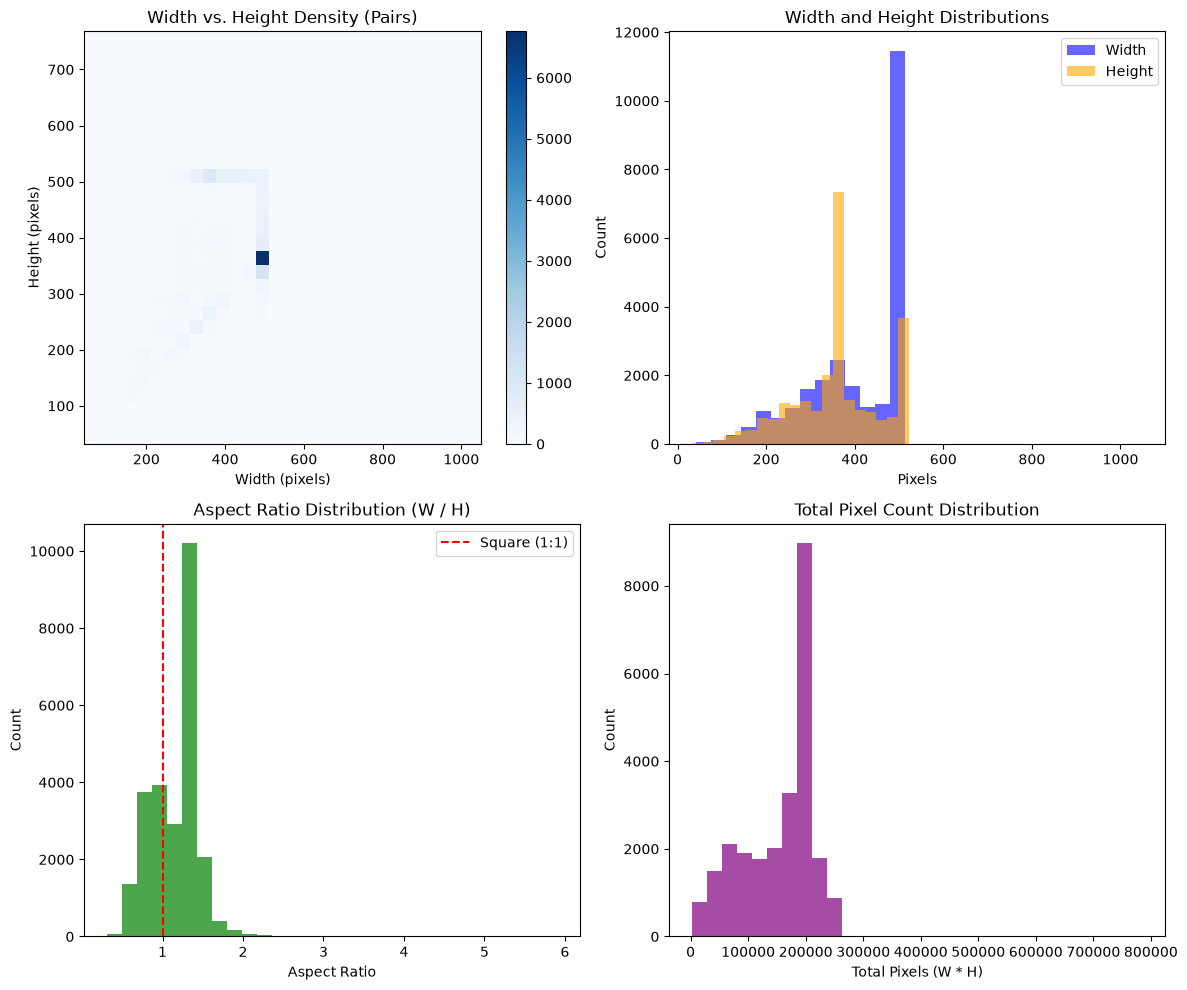

In [6]:
# Collect width, height, aspect ratio, and total pixel counts across all images
widths, heights, aspect_ratios, total_pixels = [], [], [], []

for path in file_paths:
    with Image.open(path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)
        aspect_ratios.append(w / h)
        total_pixels.append(w * h)

widths = np.array(widths)
heights = np.array(heights)
aspect_ratios = np.array(aspect_ratios)
total_pixels = np.array(total_pixels)

# 1. Print Detailed Descriptive Statistics
print("=== RESOLUTION METRICS ===")
print(f"Width  -> Mean: {widths.mean():.1f} | Std: {widths.std():.1f} | Median: {np.median(widths):.1f} | Min: {widths.min()} | Max: {widths.max()}")
print(f"Height -> Mean: {heights.mean():.1f} | Std: {heights.std():.1f} | Median: {np.median(heights):.1f} | Min: {heights.min()} | Max: {heights.max()}")

print("\n=== LOW-RESOLUTION ANALYSIS ===")
low_res_threshold = 128 * 128  # e.g. equivalent to 128x128 pixel area
count_below_thresh = np.sum(total_pixels < low_res_threshold)
pct_below_thresh = (count_below_thresh / len(total_pixels)) * 100
print(f"Images with area < 128x128 ({low_res_threshold} px): {count_below_thresh} / {len(total_pixels)} ({pct_below_thresh:.2f}%)")

low_res_64 = 64 * 64
count_below_64 = np.sum(total_pixels < low_res_64)
pct_below_64 = (count_below_64 / len(total_pixels)) * 100
print(f"Images with area < 64x64 ({low_res_64} px): {count_below_64} / {len(total_pixels)} ({pct_below_64:.2f}%)")

# 2. Plot Visual Distribution & Resolution Pairs
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Subplot 1: 2D Joint Histogram (Width vs Height Pairs)
h2d = axs[0, 0].hist2d(widths, heights, bins=30, cmap='Blues')
axs[0, 0].set_title('Width vs. Height Density (Pairs)')
axs[0, 0].set_xlabel('Width (pixels)')
axs[0, 0].set_ylabel('Height (pixels)')
fig.colorbar(h2d[3], ax=axs[0, 0])

# Subplot 2: Individual Dimension Histograms
axs[0, 1].hist(widths, bins=30, alpha=0.6, color='blue', label='Width')
axs[0, 1].hist(heights, bins=30, alpha=0.6, color='orange', label='Height')
axs[0, 1].set_title('Width and Height Distributions')
axs[0, 1].set_xlabel('Pixels')
axs[0, 1].set_ylabel('Count')
axs[0, 1].legend()

# Subplot 3: Aspect Ratio Histogram
axs[1, 0].hist(aspect_ratios, bins=30, color='green', alpha=0.7)
axs[1, 0].axvline(1.0, color='red', linestyle='--', label='Square (1:1)')
axs[1, 0].set_title('Aspect Ratio Distribution (W / H)')
axs[1, 0].set_xlabel('Aspect Ratio')
axs[1, 0].set_ylabel('Count')
axs[1, 0].legend()

# Subplot 4: Total Pixels (Resolution Area) Histogram
axs[1, 1].hist(total_pixels, bins=30, color='purple', alpha=0.7)
axs[1, 1].set_title('Total Pixel Count Distribution')
axs[1, 1].set_xlabel('Total Pixels (W * H)')
axs[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [7]:
TARGET_SIZE = (64, 64)

def extract_features_from_path(path):
    """
    Reads an image path, converts to grayscale, resizes, 
    and returns the combined feature vector (Raw Pixels + HOG).
    """
    # 1. Fast read directly in Grayscale mode via OpenCV
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    
    # 2. Resize to 64x64 using Area interpolation (ideal for downsampling)
    img_resized = cv2.resize(img, TARGET_SIZE, interpolation=cv2.INTER_AREA)
    
    # 3. Raw Pixels [4,096 features]
    raw_pixels = (img_resized.astype(np.float32) / 255.0).ravel()
    
    # 4. HOG Features [1,764 features]
    hog_feats = hog(
        img_resized,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=False
    )
    
    # 5. Combined Vector [5,860 features]
    return np.hstack((raw_pixels, hog_feats))

print(f"Extracting features for {len(file_paths)} images across CPU cores...")

# joblib's Parallel works reliably in Windows Jupyter Notebooks
# n_jobs=-1 uses all available i7 CPU threads
results = Parallel(n_jobs=-1, batch_size=64, verbose=10)(
    delayed(extract_features_from_path)(path) for path in file_paths
)

# Convert results into a continuous C-contiguous float32 numpy matrix
X = np.array(results, dtype=np.float32)
y = labels.astype(np.int32)

print(f"\nSuccessfully created Feature Matrix!")
print(f"Matrix Shape: {X.shape} (Samples x Features)")
print(f"Memory Allocation: {X.nbytes / (1024**2):.2f} MB")

Extracting features for 25000 images across CPU cores...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 104 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 680 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done 1384 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done 2088 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 2920 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done 3752 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 4712 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done 5672 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done 6760 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done 7848 tasks      | elapsed:    4.3s
[Parallel(n_jobs=-1)]: Done 9064 tasks      | elapsed:    4.8s
[Parallel(n_jobs=-1)]: Done 10280 tasks      | elapsed:    5.2s
[Parallel(n_jobs=-1)]: Done 11624 tasks     


Successfully created Feature Matrix!
Matrix Shape: (25000, 5860) (Samples x Features)
Memory Allocation: 558.85 MB


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Stratified 80/20 split (20,000 train samples / 5,000 test samples)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("=== DATA SPLIT COMPLETE ===")
print(f"Training set: {X_train.shape[0]} samples (Cats: {np.sum(y_train==0)}, Dogs: {np.sum(y_train==1)})")
print(f"Testing set:  {X_test.shape[0]} samples (Cats: {np.sum(y_test==0)}, Dogs: {np.sum(y_test==1)})")

# Initialize and fit StandardScaler on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("StandardScaler fitted and applied successfully.")

=== DATA SPLIT COMPLETE ===
Training set: 20000 samples (Cats: 10000, Dogs: 10000)
Testing set:  5000 samples (Cats: 2500, Dogs: 2500)
StandardScaler fitted and applied successfully.


In [9]:
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Separate indices by class label from the full dataset
cat_indices = np.where(labels == 0)[0]
dog_indices = np.where(labels == 1)[0]

# 2. Select exactly 1,500 Cats and 1,500 Dogs (3,000 total)
#    - Train: 1,000 Cats + 1,000 Dogs = 2,000 samples
#    - Test:    500 Cats +   500 Dogs = 1,000 samples
selected_cat_indices = np.random.choice(cat_indices, size=1500, replace=False)
selected_dog_indices = np.random.choice(dog_indices, size=1500, replace=False)

# Combine selected indices and gather corresponding file paths & labels
subset_indices = np.hstack((selected_cat_indices, selected_dog_indices))
subset_paths = file_paths[subset_indices]
subset_labels = labels[subset_indices]

# 3. Stratified Split into Train (2,000 images) and Test (1,000 images)
train_paths, test_paths, y_train, y_test = train_test_split(
    subset_paths, 
    subset_labels, 
    test_size=1000,           # Exact test size requested
    train_size=2000,          # Exact train size requested (1000 cats, 1000 dogs)
    stratify=subset_labels,   # Guarantees equal cat/dog distribution
    random_state=42
)

print("=== SUBSAMPLED DATASET SPLIT ===")
print(f"Training Set : {len(train_paths)} total images")
print(f"  - Cats (0) : {np.sum(y_train == 0)}")
print(f"  - Dogs (1) : {np.sum(y_train == 1)}")
print(f"\nTesting Set  : {len(test_paths)} total images")
print(f"  - Cats (0) : {np.sum(y_test == 0)}")
print(f"  - Dogs (1) : {np.sum(y_test == 1)}")

=== SUBSAMPLED DATASET SPLIT ===
Training Set : 2000 total images
  - Cats (0) : 1000
  - Dogs (1) : 1000

Testing Set  : 1000 total images
  - Cats (0) : 500
  - Dogs (1) : 500


In [10]:
import cv2
import numpy as np
from scipy.stats import skew, kurtosis
from skimage.feature import hog, local_binary_pattern, graycomatrix, graycoprops
from joblib import Parallel, delayed

TARGET_SIZE = (64, 64)

def extract_lightweight_features(path):
    """
    Extracts ~71 compact features per image (Geometric, Hu Moments, 
    Intensity/Contrast, Texture, Edge, and Coarse HOG).
    """
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = cv2.resize(img, TARGET_SIZE, interpolation=cv2.INTER_AREA)
    
    # -------------------------------------------------------------
    # A. FOREGROUND MASK & GEOMETRIC FEATURES (8 features)
    # -------------------------------------------------------------
    blurred = cv2.GaussianBlur(img, (5, 5), 0)
    _, mask = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    mask_clean = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    
    contours, _ = cv2.findContours(mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if contours:
        c = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(c)
        perimeter = cv2.arcLength(c, True)
        
        x, y, w, h = cv2.boundingRect(c)
        bbox_area = w * h
        extent = area / bbox_area if bbox_area > 0 else 0.0
        
        hull = cv2.convexHull(c)
        hull_area = cv2.contourArea(hull)
        solidity = area / hull_area if hull_area > 0 else 0.0
        
        compactness = (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0.0
        aspect_ratio = float(w) / h if h > 0 else 0.0
        
        M = cv2.moments(c)
        if M["m00"] != 0:
            cx = (M["m10"] / M["m00"]) / TARGET_SIZE[0]
            cy = (M["m01"] / M["m00"]) / TARGET_SIZE[1]
        else:
            cx, cy = 0.5, 0.5
    else:
        area, perimeter, extent, solidity, compactness, aspect_ratio, cx, cy = 0, 0, 0, 0, 0, 0, 0.5, 0.5

    geom_feats = np.array([
        area / (TARGET_SIZE[0] * TARGET_SIZE[1]),
        perimeter / (2 * (TARGET_SIZE[0] + TARGET_SIZE[1])),
        extent, solidity, compactness, aspect_ratio, cx, cy
    ], dtype=np.float32)

    # -------------------------------------------------------------
    # B. HU MOMENTS (7 features)
    # -------------------------------------------------------------
    moments = cv2.moments(mask_clean)
    hu = cv2.HuMoments(moments).flatten()
    hu_log = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)

    # -------------------------------------------------------------
    # C. INTENSITY & CONTRAST STATISTICS (10 features)
    # -------------------------------------------------------------
    fg_pixels = img[mask_clean > 0]
    if len(fg_pixels) == 0:
        fg_pixels = img.flatten()
        
    mean_val = np.mean(fg_pixels)
    std_val = np.std(fg_pixels)
    var_val = np.var(fg_pixels)
    skew_val = float(skew(fg_pixels))
    kurt_val = float(kurtosis(fg_pixels))
    min_val = np.min(fg_pixels)
    max_val = np.max(fg_pixels)
    dyn_range = max_val - min_val
    median_val = np.median(fg_pixels)
    rms_contrast = np.sqrt(np.mean((fg_pixels - mean_val) ** 2))

    intensity_feats = np.array([
        mean_val / 255.0, std_val / 255.0, var_val / (255.0 ** 2),
        skew_val, kurt_val, min_val / 255.0, max_val / 255.0,
        dyn_range / 255.0, median_val / 255.0, rms_contrast / 255.0
    ], dtype=np.float32)

    # -------------------------------------------------------------
    # D. TEXTURE — HARALICK & LBP (16 features)
    # -------------------------------------------------------------
    # GLCM at distance 1 (6 features)
    glcm = graycomatrix(img, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast').ravel()
    dissimilarity = graycoprops(glcm, 'dissimilarity').ravel()
    homogeneity = graycoprops(glcm, 'homogeneity').ravel()
    energy = graycoprops(glcm, 'energy').ravel()
    correlation = graycoprops(glcm, 'correlation').ravel()
    asm = graycoprops(glcm, 'ASM').ravel()
    glcm_feats = np.hstack((contrast, dissimilarity, homogeneity, energy, correlation, asm))

    # LBP Texture Histogram (10 features)
    lbp = local_binary_pattern(img, P=8, R=1, method='uniform')
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 11), density=True)

    # -------------------------------------------------------------
    # E. COARSE HOG (28 features - reduced from 1764)
    # -------------------------------------------------------------
    # pixels_per_cell=(16, 16) dramatically condenses structure features
    hog_feats = hog(
        img, orientations=7, pixels_per_cell=(16, 16),
        cells_per_block=(2, 2), block_norm='L2-Hys', visualize=False
    )

    # -------------------------------------------------------------
    # F. EDGE METRICS (2 features)
    # -------------------------------------------------------------
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    sobel_density = np.mean(np.hypot(sobelx, sobely)) / 255.0
    laplacian_var = cv2.Laplacian(img, cv2.CV_64F).var() / (255.0 ** 2)
    edge_feats = np.array([sobel_density, laplacian_var], dtype=np.float32)

    # Combine into final lightweight feature vector (~71 features)
    return np.hstack((
        geom_feats,
        hu_log,
        intensity_feats,
        glcm_feats,
        lbp_hist,
        hog_feats,
        edge_feats
    ))

print("Extracting compact feature vectors (~71 features/image)...")

# Parallel extraction for Training paths
X_train = np.array(Parallel(n_jobs=-1, batch_size=32)(
    delayed(extract_lightweight_features)(path) for path in train_paths
), dtype=np.float32)

# Parallel extraction for Testing paths
X_test = np.array(Parallel(n_jobs=-1, batch_size=32)(
    delayed(extract_lightweight_features)(path) for path in test_paths
), dtype=np.float32)

print("\n=== FEATURE EXTRACTION COMPLETE ===")
print(f"X_train Shape : {X_train.shape} (2000 images x {X_train.shape[1]} features)")
print(f"X_test Shape  : {X_test.shape} (1000 images x {X_test.shape[1]} features)")
print(f"Memory Allocation: {(X_train.nbytes + X_test.nbytes) / (1024**2):.2f} MB")

Extracting compact feature vectors (~71 features/image)...

=== FEATURE EXTRACTION COMPLETE ===
X_train Shape : (2000, 295) (2000 images x 295 features)
X_test Shape  : (1000, 295) (1000 images x 295 features)
Memory Allocation: 3.38 MB


In [11]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both train and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=== FEATURE STANDARDIZATION COMPLETE ===")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape : {X_test_scaled.shape}")

=== FEATURE STANDARDIZATION COMPLETE ===
X_train_scaled shape: (2000, 295)
X_test_scaled shape : (1000, 295)


In [12]:
import time
from sklearn.svm import SVC

print("Training Support Vector Machine (SVM)...")
start_time = time.time()

# SVM with RBF kernel on standardized 295 feature vectors
svm_clf = SVC(kernel='rbf', C=1.0, random_state=42)
svm_clf.fit(X_train_scaled, y_train)

elapsed = time.time() - start_time
print(f"SVM Training Completed in {elapsed:.2f} seconds!")

Training Support Vector Machine (SVM)...
SVM Training Completed in 0.25 seconds!


In [13]:
print("Testing SVM model on 1,000 test images...")

# Predict labels for test set
svm_preds = svm_clf.predict(X_test_scaled)

print("SVM Prediction Complete!")

Testing SVM model on 1,000 test images...
SVM Prediction Complete!


In [14]:
import time
from sklearn.neural_network import MLPClassifier

print("Training Multi-Layer Perceptron (MLP)...")
start_time = time.time()

mlp_clf = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=150,
    random_state=42,
    early_stopping=True,
    n_iter_no_change=5
)

mlp_clf.fit(X_train_scaled, y_train)

elapsed = time.time() - start_time
print(f"MLP Training Completed in {elapsed:.2f} seconds!")

Training Multi-Layer Perceptron (MLP)...
MLP Training Completed in 0.26 seconds!


In [15]:
print("Testing MLP model on 1,000 test images...")

# Predict labels for test set
mlp_preds = mlp_clf.predict(X_test_scaled)

print("MLP Prediction Complete!")

Testing MLP model on 1,000 test images...
MLP Prediction Complete!


====================== CLASSIFICATION PERFORMANCE COMPARISON ======================


,Accuracy,Sensitivity (Recall),Specificity,Precision,F1-Score,Dice Coefficient
SVM Model,74.80%,72.00%,77.60%,76.27%,74.07%,74.07%
MLP Model,70.40%,67.20%,73.60%,71.79%,69.42%,69.42%


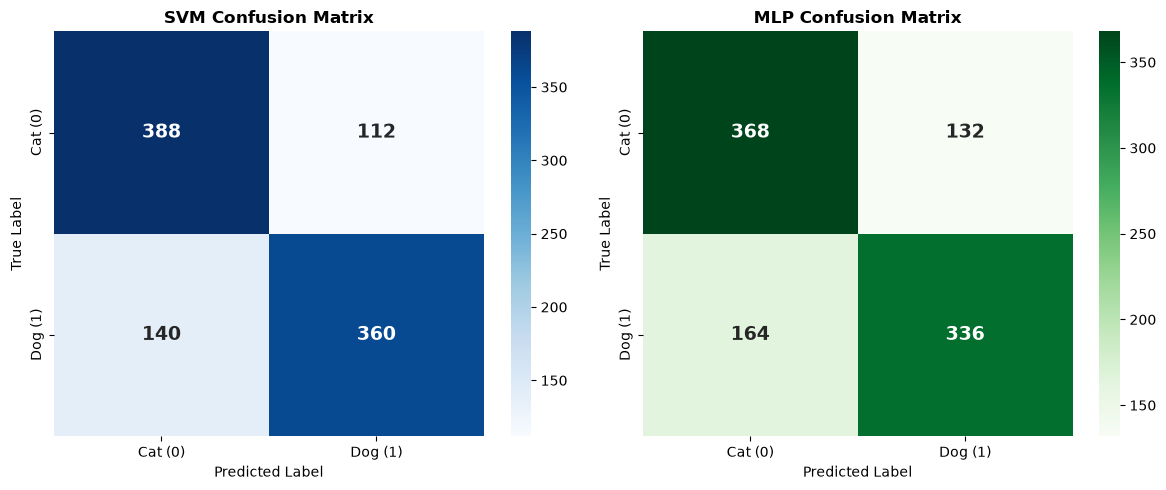

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import IPython.display as ipd
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

def compute_all_metrics(y_true, y_pred):
    """
    Computes confusion matrix and detailed performance metrics.
    Positive Class = Dog (1), Negative Class = Cat (0).
    """
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()
    
    acc = accuracy_score(y_true, y_pred)
    sensitivity = recall_score(y_true, y_pred)            # Recall: TP / (TP + FN)
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0   # True Negative Rate: TN / (TN + FP)
    precision = precision_score(y_true, y_pred)            # Precision: TP / (TP + FP)
    f1 = f1_score(y_true, y_pred)                          # F1 Score
    dice = (2 * TP) / (2 * TP + FP + FN)                    # Dice Coefficient
    
    return {
        "Accuracy": f"{acc * 100:.2f}%",
        "Sensitivity (Recall)": f"{sensitivity * 100:.2f}%",
        "Specificity": f"{specificity * 100:.2f}%",
        "Precision": f"{precision * 100:.2f}%",
        "F1-Score": f"{f1 * 100:.2f}%",
        "Dice Coefficient": f"{dice * 100:.2f}%",
        "TP": TP, "TN": TN, "FP": FP, "FN": FN
    }, cm

# 1. Compute metrics for both models
svm_metrics, cm_svm = compute_all_metrics(y_test, svm_preds)
mlp_metrics, cm_mlp = compute_all_metrics(y_test, mlp_preds)

# 2. Display Metrics Table
metrics_df = pd.DataFrame([svm_metrics, mlp_metrics], index=["SVM Model", "MLP Model"])
print("====================== CLASSIFICATION PERFORMANCE COMPARISON ======================")
ipd.display(metrics_df[["Accuracy", "Sensitivity (Recall)", "Specificity", "Precision", "F1-Score", "Dice Coefficient"]])

# 3. Plot Confusion Matrices Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# SVM Confusion Matrix
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Cat (0)', 'Dog (1)'], yticklabels=['Cat (0)', 'Dog (1)'],
            annot_kws={"size": 14, "weight": "bold"})
axes[0].set_title('SVM Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# MLP Confusion Matrix
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Cat (0)', 'Dog (1)'], yticklabels=['Cat (0)', 'Dog (1)'],
            annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title('MLP Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

In [20]:
import cv2
import numpy as np
from scipy.stats import skew, kurtosis
from skimage.feature import hog, local_binary_pattern, graycomatrix, graycoprops
from joblib import Parallel, delayed

TARGET_SIZE = (64, 64)

def extract_features_with_color(path):
    """
    Extracts geometric, Hu moments, intensity, texture, edge, coarse HOG, 
    AND Color Features (HSV & Lab statistics + HSV Color Histogram).
    """
    # 1. Read Image in BGR (Color) and Gray
    img_bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    if img_bgr is None:
        return None
    img_bgr = cv2.resize(img_bgr, TARGET_SIZE, interpolation=cv2.INTER_AREA)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    
    # -------------------------------------------------------------
    # A. FOREGROUND MASK & GEOMETRIC FEATURES (8 features)
    # -------------------------------------------------------------
    blurred = cv2.GaussianBlur(img_gray, (5, 5), 0)
    _, mask = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    mask_clean = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    
    contours, _ = cv2.findContours(mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if contours:
        c = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(c)
        perimeter = cv2.arcLength(c, True)
        
        x, y, w, h = cv2.boundingRect(c)
        bbox_area = w * h
        extent = area / bbox_area if bbox_area > 0 else 0.0
        
        hull = cv2.convexHull(c)
        hull_area = cv2.contourArea(hull)
        solidity = area / hull_area if hull_area > 0 else 0.0
        
        compactness = (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0.0
        aspect_ratio = float(w) / h if h > 0 else 0.0
        
        M = cv2.moments(c)
        if M["m00"] != 0:
            cx = (M["m10"] / M["m00"]) / TARGET_SIZE[0]
            cy = (M["m01"] / M["m00"]) / TARGET_SIZE[1]
        else:
            cx, cy = 0.5, 0.5
    else:
        area, perimeter, extent, solidity, compactness, aspect_ratio, cx, cy = 0, 0, 0, 0, 0, 0, 0.5, 0.5

    geom_feats = np.array([
        area / (TARGET_SIZE[0] * TARGET_SIZE[1]),
        perimeter / (2 * (TARGET_SIZE[0] + TARGET_SIZE[1])),
        extent, solidity, compactness, aspect_ratio, cx, cy
    ], dtype=np.float32)

    # -------------------------------------------------------------
    # B. HU MOMENTS (7 features)
    # -------------------------------------------------------------
    moments = cv2.moments(mask_clean)
    hu = cv2.HuMoments(moments).flatten()
    hu_log = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)

    # -------------------------------------------------------------
    # C. INTENSITY & CONTRAST STATISTICS (10 features)
    # -------------------------------------------------------------
    fg_pixels = img_gray[mask_clean > 0]
    if len(fg_pixels) == 0:
        fg_pixels = img_gray.flatten()
        
    mean_val = np.mean(fg_pixels)
    std_val = np.std(fg_pixels)
    var_val = np.var(fg_pixels)
    skew_val = float(skew(fg_pixels))
    kurt_val = float(kurtosis(fg_pixels))
    min_val = np.min(fg_pixels)
    max_val = np.max(fg_pixels)
    dyn_range = max_val - min_val
    median_val = np.median(fg_pixels)
    rms_contrast = np.sqrt(np.mean((fg_pixels - mean_val) ** 2))

    intensity_feats = np.array([
        mean_val / 255.0, std_val / 255.0, var_val / (255.0 ** 2),
        skew_val, kurt_val, min_val / 255.0, max_val / 255.0,
        dyn_range / 255.0, median_val / 255.0, rms_contrast / 255.0
    ], dtype=np.float32)

    # -------------------------------------------------------------
    # D. NEW: COLOR FEATURES (HSV & Lab Spaces)
    # -------------------------------------------------------------
    # Convert BGR to HSV and CIE Lab color spaces
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)

    # Channel-wise mean and std for HSV and Lab
    hsv_mean, hsv_std = cv2.meanStdDev(img_hsv, mask=mask_clean)
    lab_mean, lab_std = cv2.meanStdDev(img_lab, mask=mask_clean)

    color_stats = np.hstack((
        hsv_mean.ravel() / 255.0, hsv_std.ravel() / 255.0,
        lab_mean.ravel() / 255.0, lab_std.ravel() / 255.0
    )).astype(np.float32)  # 12 features

    # Compact 3D HSV Color Histogram (4x4x4 = 64 bins)
    hist_hsv = cv2.calcHist([img_hsv], [0, 1, 2], mask_clean, [4, 4, 4], [0, 180, 0, 256, 0, 256])
    cv2.normalize(hist_hsv, hist_hsv)
    color_hist_feats = hist_hsv.flatten().astype(np.float32)  # 64 features

    # -------------------------------------------------------------
    # E. TEXTURE — HARALICK & LBP (16 features)
    # -------------------------------------------------------------
    glcm = graycomatrix(img_gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast').ravel()
    dissimilarity = graycoprops(glcm, 'dissimilarity').ravel()
    homogeneity = graycoprops(glcm, 'homogeneity').ravel()
    energy = graycoprops(glcm, 'energy').ravel()
    correlation = graycoprops(glcm, 'correlation').ravel()
    asm = graycoprops(glcm, 'ASM').ravel()
    glcm_feats = np.hstack((contrast, dissimilarity, homogeneity, energy, correlation, asm))

    lbp = local_binary_pattern(img_gray, P=8, R=1, method='uniform')
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 11), density=True)

    # -------------------------------------------------------------
    # F. COARSE HOG (28 features)
    # -------------------------------------------------------------
    hog_feats = hog(
        img_gray, orientations=7, pixels_per_cell=(16, 16),
        cells_per_block=(2, 2), block_norm='L2-Hys', visualize=False
    )

    # -------------------------------------------------------------
    # G. EDGE METRICS (2 features)
    # -------------------------------------------------------------
    sobelx = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)
    sobel_density = np.mean(np.hypot(sobelx, sobely)) / 255.0
    laplacian_var = cv2.Laplacian(img_gray, cv2.CV_64F).var() / (255.0 ** 2)
    edge_feats = np.array([sobel_density, laplacian_var], dtype=np.float32)

    # Combine all feature vectors together
    return np.hstack((
        geom_feats,
        hu_log,
        intensity_feats,
        color_stats,
        color_hist_feats,
        glcm_feats,
        lbp_hist,
        hog_feats,
        edge_feats
    ))

print("Extracting features (including Color features) for Train (2,000) and Test (1,000)...")

X_train = np.array(Parallel(n_jobs=-1, batch_size=32)(
    delayed(extract_features_with_color)(path) for path in train_paths
), dtype=np.float32)

X_test = np.array(Parallel(n_jobs=-1, batch_size=32)(
    delayed(extract_features_with_color)(path) for path in test_paths
), dtype=np.float32)

print("\n=== COLOR FEATURE EXTRACTION COMPLETE ===")
print(f"X_train Shape : {X_train.shape} (2000 images x {X_train.shape[1]} features)")
print(f"X_test Shape  : {X_test.shape} (1000 images x {X_test.shape[1]} features)")

Extracting features (including Color features) for Train (2,000) and Test (1,000)...

=== COLOR FEATURE EXTRACTION COMPLETE ===
X_train Shape : (2000, 371) (2000 images x 371 features)
X_test Shape  : (1000, 371) (1000 images x 371 features)


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("StandardScaler re-fitted on new feature matrix.")

StandardScaler re-fitted on new feature matrix.


In [22]:
import time
from sklearn.svm import SVC

print("Training SVM with Color Features...")
start_time = time.time()

svm_clf = SVC(kernel='rbf', C=1.0, random_state=42)
svm_clf.fit(X_train_scaled, y_train)

print(f"SVM Training Completed in {time.time() - start_time:.2f} seconds!")
svm_preds = svm_clf.predict(X_test_scaled)

Training SVM with Color Features...
SVM Training Completed in 0.53 seconds!


In [23]:
from sklearn.neural_network import MLPClassifier

print("Training MLP with Color Features...")
start_time = time.time()

mlp_clf = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=150,
    random_state=42,
    early_stopping=True,
    n_iter_no_change=5
)

mlp_clf.fit(X_train_scaled, y_train)

print(f"MLP Training Completed in {time.time() - start_time:.2f} seconds!")
mlp_preds = mlp_clf.predict(X_test_scaled)

Training MLP with Color Features...
MLP Training Completed in 0.27 seconds!


====================== CLASSIFICATION PERFORMANCE COMPARISON (WITH COLOR) ======================


,Accuracy,Sensitivity (Recall),Specificity,Precision,F1-Score,Dice Coefficient
SVM Model,74.90%,71.80%,78.00%,76.55%,74.10%,74.10%
MLP Model,73.50%,71.60%,75.40%,74.43%,72.99%,72.99%


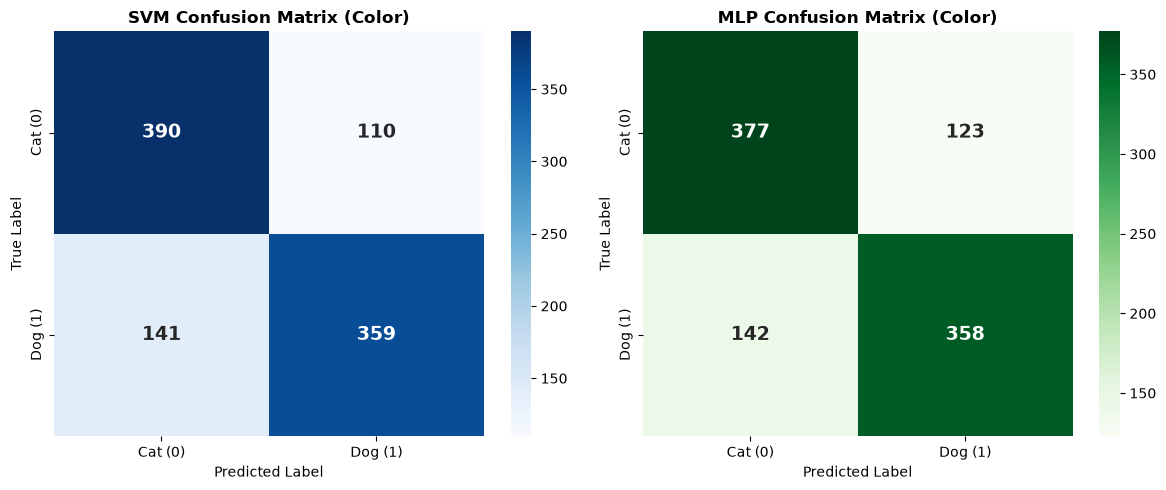

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import IPython.display as ipd
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

def compute_all_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()
    
    acc = accuracy_score(y_true, y_pred)
    sensitivity = recall_score(y_true, y_pred)
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    precision = precision_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    dice = (2 * TP) / (2 * TP + FP + FN)
    
    return {
        "Accuracy": f"{acc * 100:.2f}%",
        "Sensitivity (Recall)": f"{sensitivity * 100:.2f}%",
        "Specificity": f"{specificity * 100:.2f}%",
        "Precision": f"{precision * 100:.2f}%",
        "F1-Score": f"{f1 * 100:.2f}%",
        "Dice Coefficient": f"{dice * 100:.2f}%",
        "TP": TP, "TN": TN, "FP": FP, "FN": FN
    }, cm

svm_metrics, cm_svm = compute_all_metrics(y_test, svm_preds)
mlp_metrics, cm_mlp = compute_all_metrics(y_test, mlp_preds)

metrics_df = pd.DataFrame([svm_metrics, mlp_metrics], index=["SVM Model", "MLP Model"])
print("====================== CLASSIFICATION PERFORMANCE COMPARISON (WITH COLOR) ======================")
ipd.display(metrics_df[["Accuracy", "Sensitivity (Recall)", "Specificity", "Precision", "F1-Score", "Dice Coefficient"]])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Cat (0)', 'Dog (1)'], yticklabels=['Cat (0)', 'Dog (1)'],
            annot_kws={"size": 14, "weight": "bold"})
axes[0].set_title('SVM Confusion Matrix (Color)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Cat (0)', 'Dog (1)'], yticklabels=['Cat (0)', 'Dog (1)'],
            annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title('MLP Confusion Matrix (Color)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

In [26]:
import time
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Fast, focused parameter grid for SVM
svm_param_grid = {
    'C': [0.5, 1, 5, 10],
    'kernel': ['rbf'],
    'gamma': ['scale', 0.001, 0.005]
}

print("Starting Fast GridSearchCV for SVM...")
start_time = time.time()

svm_grid = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=svm_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=4,          # Limit parallel jobs to prevent CPU thrashing
    verbose=1
)

svm_grid.fit(X_train_scaled, y_train)

print(f"\nSVM Grid Search Completed in {time.time() - start_time:.2f} seconds!")
print(f"Best Parameters Found: {svm_grid.best_params_}")
print(f"Best CV Training Accuracy: {svm_grid.best_score_ * 100:.2f}%")

# Retrieve best tuned SVM model
svm_clf = svm_grid.best_estimator_

# Predict on Test Set
svm_preds = svm_clf.predict(X_test_scaled)

Starting Fast GridSearchCV for SVM...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

SVM Grid Search Completed in 7.88 seconds!
Best Parameters Found: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Training Accuracy: 72.95%


In [27]:
import time
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

# Define Hyperparameter Search Space for MLP
mlp_param_grid = {
    'hidden_layer_sizes': [(128, 64), (256, 128), (128, 64, 32)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.0005]
}

print("Starting GridSearchCV for MLP (5-Fold Cross Validation)...")
start_time = time.time()

mlp_grid = GridSearchCV(
    estimator=MLPClassifier(
        max_iter=200, 
        random_state=42, 
        early_stopping=True, 
        n_iter_no_change=5
    ),
    param_grid=mlp_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

mlp_grid.fit(X_train_scaled, y_train)

print(f"\nMLP Grid Search Completed in {time.time() - start_time:.2f} seconds!")
print(f"Best Parameters Found: {mlp_grid.best_params_}")
print(f"Best CV Training Accuracy: {mlp_grid.best_score_ * 100:.2f}%")

# Retrieve best tuned MLP model
mlp_clf = mlp_grid.best_estimator_

# Predict on Test Set
mlp_preds = mlp_clf.predict(X_test_scaled)

Starting GridSearchCV for MLP (5-Fold Cross Validation)...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

MLP Grid Search Completed in 27.63 seconds!
Best Parameters Found: {'activation': 'tanh', 'alpha': 0.01, 'hidden_layer_sizes': (256, 128), 'learning_rate_init': 0.0005}
Best CV Training Accuracy: 72.30%


====================== TUNED CLASSIFICATION PERFORMANCE COMPARISON ======================


,Accuracy,Sensitivity (Recall),Specificity,Precision,F1-Score,Dice Coefficient
Tuned SVM Model,74.90%,71.80%,78.00%,76.55%,74.10%,74.10%
Tuned MLP Model,71.10%,73.40%,68.80%,70.17%,71.75%,71.75%


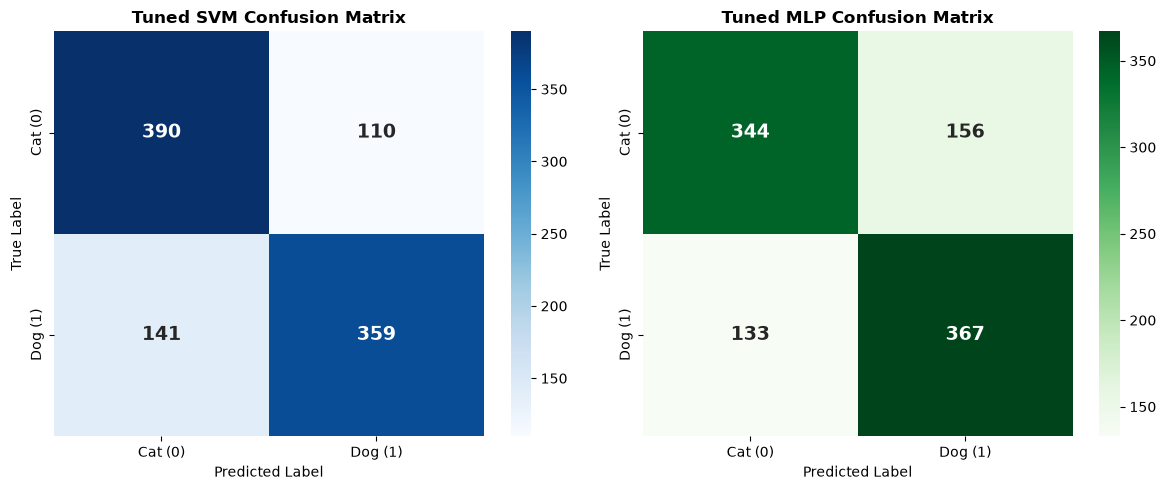

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import IPython.display as ipd
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

def compute_all_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()
    
    acc = accuracy_score(y_true, y_pred)
    sensitivity = recall_score(y_true, y_pred)
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    precision = precision_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    dice = (2 * TP) / (2 * TP + FP + FN)
    
    return {
        "Accuracy": f"{acc * 100:.2f}%",
        "Sensitivity (Recall)": f"{sensitivity * 100:.2f}%",
        "Specificity": f"{specificity * 100:.2f}%",
        "Precision": f"{precision * 100:.2f}%",
        "F1-Score": f"{f1 * 100:.2f}%",
        "Dice Coefficient": f"{dice * 100:.2f}%",
        "TP": TP, "TN": TN, "FP": FP, "FN": FN
    }, cm

svm_metrics, cm_svm = compute_all_metrics(y_test, svm_preds)
mlp_metrics, cm_mlp = compute_all_metrics(y_test, mlp_preds)

metrics_df = pd.DataFrame([svm_metrics, mlp_metrics], index=["Tuned SVM Model", "Tuned MLP Model"])
print("====================== TUNED CLASSIFICATION PERFORMANCE COMPARISON ======================")
ipd.display(metrics_df[["Accuracy", "Sensitivity (Recall)", "Specificity", "Precision", "F1-Score", "Dice Coefficient"]])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Cat (0)', 'Dog (1)'], yticklabels=['Cat (0)', 'Dog (1)'],
            annot_kws={"size": 14, "weight": "bold"})
axes[0].set_title('Tuned SVM Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Cat (0)', 'Dog (1)'], yticklabels=['Cat (0)', 'Dog (1)'],
            annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title('Tuned MLP Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

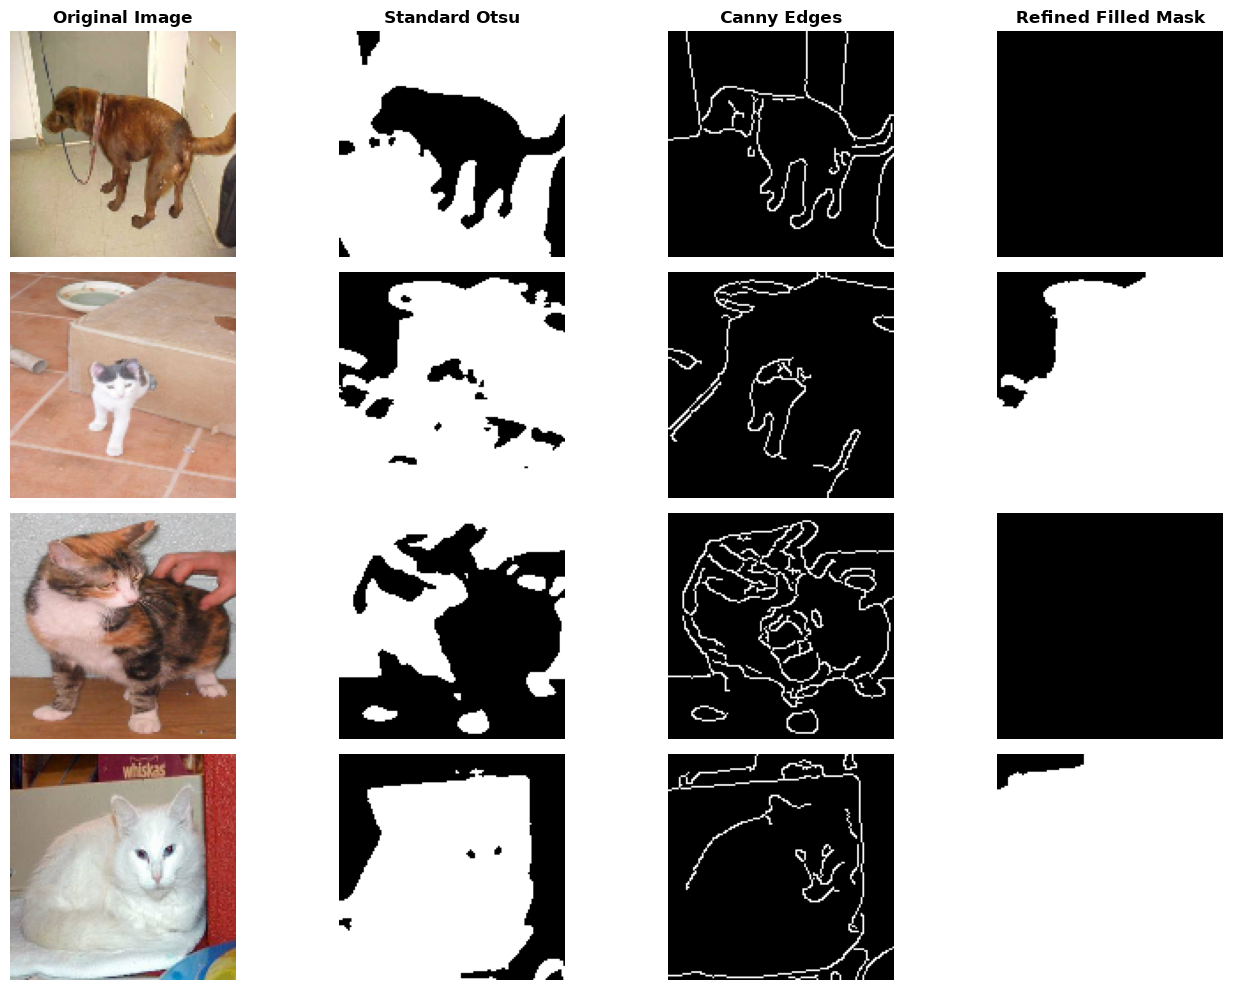

In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def inspect_mask_pipeline(img_path):
    # 1. Read & Resize
    img_bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)
    if img_bgr is None:
        return
    img_bgr = cv2.resize(img_bgr, (128, 128))
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    
    # 2. Median Blur + Otsu (Current approach baseline)
    median_blur = cv2.medianBlur(img_gray, 5)
    _, otsu_mask = cv2.threshold(median_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # 3. Edge-Guided Hole Filling (Canny + Morphology)
    edges = cv2.Canny(median_blur, 50, 150)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    closed_edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)
    
    # Combine Otsu Mask with Edge Mask
    combined_mask = cv2.bitwise_or(otsu_mask, closed_edges)
    
    # 4. Fill Internal Holes using FloodFill
    desat = combined_mask.copy()
    h, w = desat.shape[:2]
    flood_mask = np.zeros((h + 2, w + 2), np.uint8)
    cv2.floodFill(desat, flood_mask, (0, 0), 255)
    desat_inv = cv2.bitwise_not(desat)
    filled_mask = cv2.bitwise_or(combined_mask, desat_inv)
    
    # 5. Extract Primary Foreground Contour
    contours, _ = cv2.findContours(filled_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    final_mask = np.zeros_like(filled_mask)
    if contours:
        c = max(contours, key=cv2.contourArea)
        cv2.drawContours(final_mask, [c], -1, 255, thickness=cv2.FILLED)
        
    return img_bgr, otsu_mask, edges, final_mask

# Plot comparison across 4 random sample images (2 cats, 2 dogs)
sample_paths = [train_paths[0], train_paths[1], train_paths[1000], train_paths[1001]]

fig, axes = plt.subplots(len(sample_paths), 4, figsize=(14, 10))
cols = ['Original Image', 'Standard Otsu', 'Canny Edges', 'Refined Filled Mask']

for i, col in enumerate(cols):
    axes[0, i].set_title(col, fontsize=12, fontweight='bold')

for idx, path in enumerate(sample_paths):
    img_bgr, otsu_mask, edges, final_mask = inspect_mask_pipeline(path)
    
    axes[idx, 0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    axes[idx, 1].imshow(otsu_mask, cmap='gray')
    axes[idx, 2].imshow(edges, cmap='gray')
    axes[idx, 3].imshow(final_mask, cmap='gray')
    
    for ax in axes[idx]:
        ax.axis('off')

plt.tight_layout()
plt.show()

In [30]:
import cv2
import numpy as np
from scipy.stats import skew, kurtosis
from skimage.feature import hog, local_binary_pattern, graycomatrix, graycoprops
from joblib import Parallel, delayed

TARGET_SIZE = (128, 128)

def extract_dense_restored_features(path):
    """
    Extracts dense, high-resolution (128x128) features without relying on mask thresholding:
    Restores edge density, sharpness, intensity stats, GLCM, LBP, HOG, and color spaces.
    """
    # 1. Load Color and Grayscale Images
    img_bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    if img_bgr is None:
        return None
    img_bgr = cv2.resize(img_bgr, TARGET_SIZE, interpolation=cv2.INTER_AREA)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    
    # -------------------------------------------------------------
    # A. RESTORED INTENSITY & CONTRAST STATS (Whole Image - 10 features)
    # -------------------------------------------------------------
    gray_flat = img_gray.flatten()
    mean_val = np.mean(gray_flat)
    std_val = np.std(gray_flat)
    var_val = np.var(gray_flat)
    skew_val = float(skew(gray_flat))
    kurt_val = float(kurtosis(gray_flat))
    min_val = np.min(gray_flat)
    max_val = np.max(gray_flat)
    dyn_range = max_val - min_val
    median_val = np.median(gray_flat)
    rms_contrast = np.sqrt(np.mean((gray_flat - mean_val) ** 2))

    intensity_feats = np.array([
        mean_val / 255.0, std_val / 255.0, var_val / (255.0 ** 2),
        skew_val, kurt_val, min_val / 255.0, max_val / 255.0,
        dyn_range / 255.0, median_val / 255.0, rms_contrast / 255.0
    ], dtype=np.float32)

    # -------------------------------------------------------------
    # B. RESTORED EDGE & SHARPNESS METRICS (2 features)
    # -------------------------------------------------------------
    sobelx = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)
    sobel_density = np.mean(np.hypot(sobelx, sobely)) / 255.0
    laplacian_var = cv2.Laplacian(img_gray, cv2.CV_64F).var() / (255.0 ** 2)
    edge_feats = np.array([sobel_density, laplacian_var], dtype=np.float32)

    # -------------------------------------------------------------
    # C. COLOR SPACE DESCRIPTORS (HSV & Lab Stats + 3D Histogram)
    # -------------------------------------------------------------
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    
    hsv_mean, hsv_std = cv2.meanStdDev(img_hsv)
    lab_mean, lab_std = cv2.meanStdDev(img_lab)
    
    color_stats = np.hstack((
        hsv_mean.ravel() / 255.0, hsv_std.ravel() / 255.0,
        lab_mean.ravel() / 255.0, lab_std.ravel() / 255.0
    )).astype(np.float32)  # 12 features

    # Compact 3D HSV Color Histogram (4x4x4 = 64 bins)
    hist_hsv = cv2.calcHist([img_hsv], [0, 1, 2], None, [4, 4, 4], [0, 180, 0, 256, 0, 256])
    cv2.normalize(hist_hsv, hist_hsv)
    color_hist_feats = hist_hsv.flatten().astype(np.float32)  # 64 features

    # -------------------------------------------------------------
    # D. RESTORED MULTI-DISTANCE TEXTURE (GLCM & LBP - 22 features)
    # -------------------------------------------------------------
    glcm = graycomatrix(img_gray, distances=[1, 3], angles=[0], levels=256, symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast').ravel()
    dissimilarity = graycoprops(glcm, 'dissimilarity').ravel()
    homogeneity = graycoprops(glcm, 'homogeneity').ravel()
    energy = graycoprops(glcm, 'energy').ravel()
    correlation = graycoprops(glcm, 'correlation').ravel()
    asm = graycoprops(glcm, 'ASM').ravel()
    glcm_feats = np.hstack((contrast, dissimilarity, homogeneity, energy, correlation, asm))  # 12 features

    lbp = local_binary_pattern(img_gray, P=8, R=1, method='uniform')
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 11), density=True)  # 10 features

    # -------------------------------------------------------------
    # E. HIGH-RESOLUTION HOG (1,764 features at 128x128)
    # -------------------------------------------------------------
    hog_feats = hog(
        img_gray, orientations=9, pixels_per_cell=(16, 16),
        cells_per_block=(2, 2), block_norm='L2-Hys', visualize=False
    )

    # Combine into unified feature vector (~1,876 features)
    return np.hstack((
        intensity_feats,
        edge_feats,
        color_stats,
        color_hist_feats,
        glcm_feats,
        lbp_hist,
        hog_feats
    ))

print("Extracting Dense Restored Feature Matrix at 128x128 resolution...")

X_train = np.array(Parallel(n_jobs=-1, batch_size=32)(
    delayed(extract_dense_restored_features)(path) for path in train_paths
), dtype=np.float32)

X_test = np.array(Parallel(n_jobs=-1, batch_size=32)(
    delayed(extract_dense_restored_features)(path) for path in test_paths
), dtype=np.float32)

print("\n=== DENSE FEATURE EXTRACTION COMPLETE ===")
print(f"X_train Shape : {X_train.shape}")
print(f"X_test Shape  : {X_test.shape}")

Extracting Dense Restored Feature Matrix at 128x128 resolution...

=== DENSE FEATURE EXTRACTION COMPLETE ===
X_train Shape : (2000, 1874)
X_test Shape  : (1000, 1874)


In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=== FEATURE STANDARDIZATION COMPLETE ===")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape : {X_test_scaled.shape}")

=== FEATURE STANDARDIZATION COMPLETE ===
X_train_scaled shape: (2000, 1874)
X_test_scaled shape : (1000, 1874)


In [34]:
import time
from sklearn.svm import SVC

print("Training SVM on 1,874 dense spatial/texture features...")
start_time = time.time()

svm_clf = SVC(kernel='rbf', C=1.0, random_state=42)
svm_clf.fit(X_train_scaled, y_train)

print(f"SVM Training Completed in {time.time() - start_time:.2f} seconds!")
svm_preds = svm_clf.predict(X_test_scaled)

Training SVM on 1,874 dense spatial/texture features...
SVM Training Completed in 2.38 seconds!


In [35]:
import time
from sklearn.neural_network import MLPClassifier

print("Training MLP on 1,874 dense spatial/texture features...")
start_time = time.time()

mlp_clf = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=150,
    random_state=42,
    early_stopping=True,
    n_iter_no_change=5
)

mlp_clf.fit(X_train_scaled, y_train)

print(f"MLP Training Completed in {time.time() - start_time:.2f} seconds!")
mlp_preds = mlp_clf.predict(X_test_scaled)

Training MLP on 1,874 dense spatial/texture features...
MLP Training Completed in 0.91 seconds!


====================== CLASSIFICATION PERFORMANCE (128x128 DENSE) ======================


,Accuracy,Sensitivity (Recall),Specificity,Precision,F1-Score,Dice Coefficient
SVM Model (128x128 Dense),76.00%,73.60%,78.40%,77.31%,75.41%,75.41%
MLP Model (128x128 Dense),73.40%,73.80%,73.00%,73.21%,73.51%,73.51%


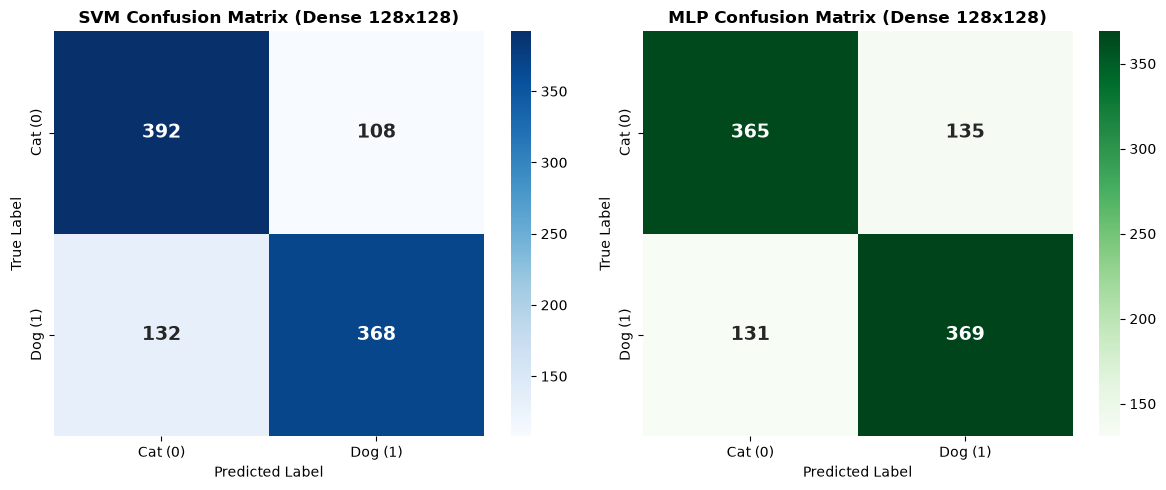

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import IPython.display as ipd
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

def compute_all_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()
    
    acc = accuracy_score(y_true, y_pred)
    sensitivity = recall_score(y_true, y_pred)
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    precision = precision_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    dice = (2 * TP) / (2 * TP + FP + FN)
    
    return {
        "Accuracy": f"{acc * 100:.2f}%",
        "Sensitivity (Recall)": f"{sensitivity * 100:.2f}%",
        "Specificity": f"{specificity * 100:.2f}%",
        "Precision": f"{precision * 100:.2f}%",
        "F1-Score": f"{f1 * 100:.2f}%",
        "Dice Coefficient": f"{dice * 100:.2f}%",
        "TP": TP, "TN": TN, "FP": FP, "FN": FN
    }, cm

svm_metrics, cm_svm = compute_all_metrics(y_test, svm_preds)
mlp_metrics, cm_mlp = compute_all_metrics(y_test, mlp_preds)

metrics_df = pd.DataFrame([svm_metrics, mlp_metrics], index=["SVM Model (128x128 Dense)", "MLP Model (128x128 Dense)"])
print("====================== CLASSIFICATION PERFORMANCE (128x128 DENSE) ======================")
ipd.display(metrics_df[["Accuracy", "Sensitivity (Recall)", "Specificity", "Precision", "F1-Score", "Dice Coefficient"]])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# SVM Confusion Matrix
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Cat (0)', 'Dog (1)'], yticklabels=['Cat (0)', 'Dog (1)'],
            annot_kws={"size": 14, "weight": "bold"})
axes[0].set_title('SVM Confusion Matrix (Dense 128x128)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# MLP Confusion Matrix
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Cat (0)', 'Dog (1)'], yticklabels=['Cat (0)', 'Dog (1)'],
            annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title('MLP Confusion Matrix (Dense 128x128)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

Total Misclassified Samples (SVM): 240 / 1000


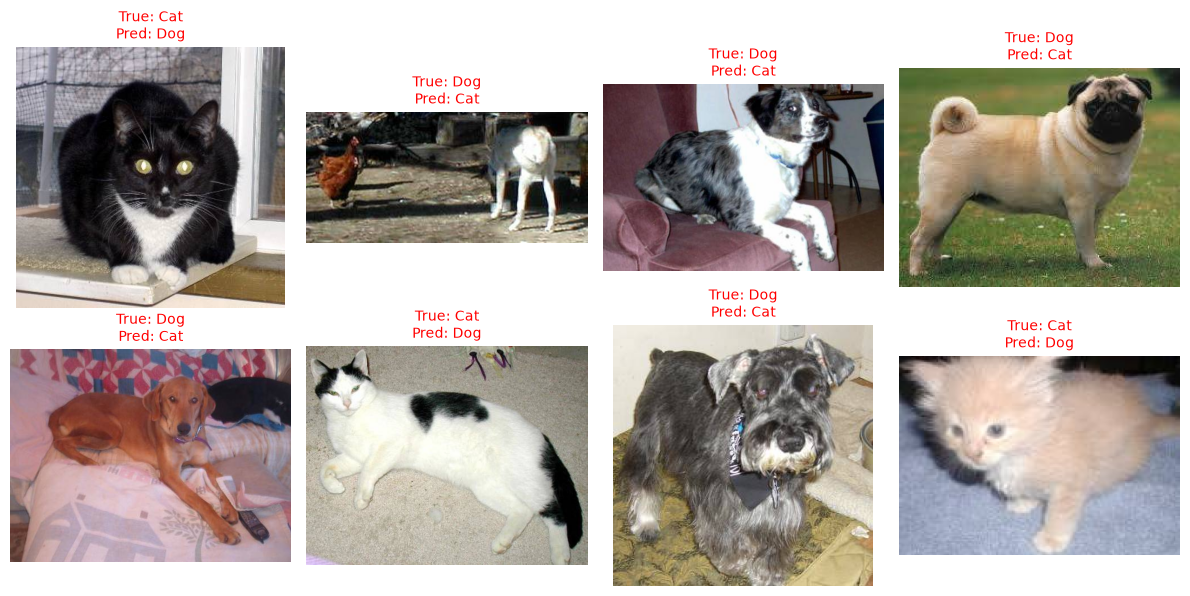

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Identify misclassified indices for SVM
misclassified_idx = np.where(y_test != svm_preds)[0]

print(f"Total Misclassified Samples (SVM): {len(misclassified_idx)} / {len(y_test)}")

# Plot first 8 misclassified images
plt.figure(figsize=(12, 6))
label_map = {0: "Cat", 1: "Dog"}

for i, idx in enumerate(misclassified_idx[:8]):
    plt.subplot(2, 4, i + 1)
    img_bgr = cv2.imread(test_paths[idx])
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) if img_bgr is not None else np.zeros((128, 128, 3))
    
    plt.imshow(img_rgb)
    plt.title(f"True: {label_map[y_test[idx]]}\nPred: {label_map[svm_preds[idx]]}", fontsize=10, color='red')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [45]:
import os
import glob
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Target your exact Kaggle dogs-vs-cats train directory
train_dir = r"C:\Users\PC-LAB1\img_processing_lab\day05\data\dogs-vs-cats\train\train"

# 2. Gather Kaggle-style file paths (cat.X.jpg and dog.X.jpg)
cat_paths = glob.glob(os.path.join(train_dir, "cat.*.jpg"))
dog_paths = glob.glob(os.path.join(train_dir, "dog.*.jpg"))

# Cap at 5,000 images each to form a balanced 10,000 dataset
cat_paths = cat_paths[:5000]
dog_paths = dog_paths[:5000]

print(f"Found {len(cat_paths)} Cat images")
print(f"Found {len(dog_paths)} Dog images")

all_paths = np.array(cat_paths + dog_paths)
all_labels = np.array([0] * len(cat_paths) + [1] * len(dog_paths))

# 3. Perform 70 / 15 / 15 Stratified Split
train_paths, temp_paths, y_train, temp_labels = train_test_split(
    all_paths, all_labels, test_size=0.30, random_state=42, stratify=all_labels
)

val_paths, test_paths, y_val, y_test = train_test_split(
    temp_paths, temp_labels, test_size=0.50, random_state=42, stratify=temp_labels
)

print("\n=== DATASET SPLIT COMPLETE ===")
print(f"Total Samples : {len(all_paths)}")
print(f"Train Set     : {len(train_paths)} images")
print(f"Val Set       : {len(val_paths)} images")
print(f"Test Set      : {len(test_paths)} images (Held out until final evaluation)")

Found 5000 Cat images
Found 5000 Dog images

=== DATASET SPLIT COMPLETE ===
Total Samples : 10000
Train Set     : 7000 images
Val Set       : 1500 images
Test Set      : 1500 images (Held out until final evaluation)


In [46]:
from scipy.stats import skew, kurtosis
from skimage.feature import hog, local_binary_pattern, graycomatrix, graycoprops

TARGET_SIZE = (128, 128)

def extract_dense_features(path):
    img_bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    if img_bgr is None:
        # Fallback for corrupt images
        return np.zeros(1874, dtype=np.float32)
    
    img_bgr = cv2.resize(img_bgr, TARGET_SIZE, interpolation=cv2.INTER_AREA)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    
    # A. Intensity & Contrast Stats (10 features)
    gray_flat = img_gray.flatten()
    mean_val = np.mean(gray_flat)
    std_val = np.std(gray_flat)
    var_val = np.var(gray_flat)
    skew_val = float(skew(gray_flat))
    kurt_val = float(kurtosis(gray_flat))
    min_val = np.min(gray_flat)
    max_val = np.max(gray_flat)
    dyn_range = max_val - min_val
    median_val = np.median(gray_flat)
    rms_contrast = np.sqrt(np.mean((gray_flat - mean_val) ** 2))

    intensity_feats = np.array([
        mean_val / 255.0, std_val / 255.0, var_val / (255.0 ** 2),
        skew_val, kurt_val, min_val / 255.0, max_val / 255.0,
        dyn_range / 255.0, median_val / 255.0, rms_contrast / 255.0
    ], dtype=np.float32)

    # B. Edge & Sharpness Metrics (2 features)
    sobelx = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)
    sobel_density = np.mean(np.hypot(sobelx, sobely)) / 255.0
    laplacian_var = cv2.Laplacian(img_gray, cv2.CV_64F).var() / (255.0 ** 2)
    edge_feats = np.array([sobel_density, laplacian_var], dtype=np.float32)

    # C. Color Descriptors: HSV & Lab Stats + 3D Color Histogram (76 features)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    
    hsv_mean, hsv_std = cv2.meanStdDev(img_hsv)
    lab_mean, lab_std = cv2.meanStdDev(img_lab)
    
    color_stats = np.hstack((
        hsv_mean.ravel() / 255.0, hsv_std.ravel() / 255.0,
        lab_mean.ravel() / 255.0, lab_std.ravel() / 255.0
    )).astype(np.float32)

    hist_hsv = cv2.calcHist([img_hsv], [0, 1, 2], None, [4, 4, 4], [0, 180, 0, 256, 0, 256])
    cv2.normalize(hist_hsv, hist_hsv)
    color_hist_feats = hist_hsv.flatten().astype(np.float32)

    # D. Multi-Distance Texture: GLCM & LBP (22 features)
    glcm = graycomatrix(img_gray, distances=[1, 3], angles=[0], levels=256, symmetric=True, normed=True)
    glcm_feats = np.hstack((
        graycoprops(glcm, 'contrast').ravel(),
        graycoprops(glcm, 'dissimilarity').ravel(),
        graycoprops(glcm, 'homogeneity').ravel(),
        graycoprops(glcm, 'energy').ravel(),
        graycoprops(glcm, 'correlation').ravel(),
        graycoprops(glcm, 'ASM').ravel()
    )).astype(np.float32)

    lbp = local_binary_pattern(img_gray, P=8, R=1, method='uniform')
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 11), density=True)

    # E. High-Resolution HOG (1,764 features)
    hog_feats = hog(
        img_gray, orientations=9, pixels_per_cell=(16, 16),
        cells_per_block=(2, 2), block_norm='L2-Hys', visualize=False
    ).astype(np.float32)

    return np.hstack((
        intensity_feats, edge_feats, color_stats,
        color_hist_feats, glcm_feats, lbp_hist, hog_feats
    ))

print("Extracting features across Train, Validation, and Test sets...")

X_train_raw = np.array(Parallel(n_jobs=-1, batch_size=32)(
    delayed(extract_dense_features)(p) for p in train_paths
), dtype=np.float32)

X_val_raw = np.array(Parallel(n_jobs=-1, batch_size=32)(
    delayed(extract_dense_features)(p) for p in val_paths
), dtype=np.float32)

X_test_raw = np.array(Parallel(n_jobs=-1, batch_size=32)(
    delayed(extract_dense_features)(p) for p in test_paths
), dtype=np.float32)

print("\n=== EXTRACTION COMPLETE ===")
print(f"X_train Shape : {X_train_raw.shape}")
print(f"X_val Shape   : {X_val_raw.shape}")
print(f"X_test Shape  : {X_test_raw.shape}")

Extracting features across Train, Validation, and Test sets...

=== EXTRACTION COMPLETE ===
X_train Shape : (7000, 1874)
X_val Shape   : (1500, 1874)
X_test Shape  : (1500, 1874)


In [47]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)
X_test_scaled = scaler.transform(X_test_raw)

# 2. PCA Compression (retaining 95% variance)
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("=== PCA COMPRESSION COMPLETE ===")
print(f"Original Dimension : {X_train_raw.shape[1]}")
print(f"Reduced Dimension  : {X_train_pca.shape[1]} components (explained 95% variance)")
print(f"X_train_pca Shape  : {X_train_pca.shape}")
print(f"X_val_pca Shape    : {X_val_pca.shape}")
print(f"X_test_pca Shape   : {X_test_pca.shape}")

=== PCA COMPRESSION COMPLETE ===
Original Dimension : 1874
Reduced Dimension  : 509 components (explained 95% variance)
X_train_pca Shape  : (7000, 509)
X_val_pca Shape    : (1500, 509)
X_test_pca Shape   : (1500, 509)


In [49]:
import time
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, classification_report

print("1. Training SVM (RBF)...")
svm = SVC(C=2.0, kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_pca, y_train)

print("2. Training MLP...")
mlp = MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=200, random_state=42, early_stopping=True)
mlp.fit(X_train_pca, y_train)

print("3. Training XGBoost...")
xgb = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42, eval_metric='logloss')
xgb.fit(X_train_pca, y_train)

print("4. Building Soft-Voting Ensemble...")
ensemble = VotingClassifier(
    estimators=[('svm', svm), ('mlp', mlp), ('xgb', xgb)],
    voting='soft'
)
ensemble.fit(X_train_pca, y_train)

# --- VALIDATION EVALUATION ---
print("\n================ VALIDATION SET ACCURACY ================")
models = {"SVM": svm, "MLP": mlp, "XGBoost": xgb, "Voting Ensemble": ensemble}

for name, model in models.items():
    val_preds = model.predict(X_val_pca)
    acc = accuracy_score(y_val, val_preds)
    print(f"-> {name:<18} Validation Accuracy: {acc * 100:.2f}%")

1. Training SVM (RBF)...


c:\Users\PC-LAB1\img_processing_lab\.imgvenv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


2. Training MLP...
3. Training XGBoost...
4. Building Soft-Voting Ensemble...


c:\Users\PC-LAB1\img_processing_lab\.imgvenv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



================ VALIDATION SET ACCURACY ================
-> SVM                Validation Accuracy: 79.93%
-> MLP                Validation Accuracy: 76.33%
-> XGBoost            Validation Accuracy: 73.20%
-> Voting Ensemble    Validation Accuracy: 78.07%


In [51]:
import pandas as pd
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

results = []

for name, model in models.items():
    test_preds = model.predict(X_test_pca)
    cm = confusion_matrix(y_test, test_preds)
    TN, FP, FN, TP = cm.ravel()
    
    results.append({
        "Model": name,
        "Accuracy": f"{accuracy_score(y_test, test_preds) * 100:.2f}%",
        "Sensitivity": f"{recall_score(y_test, test_preds) * 100:.2f}%",
        "Specificity": f"{TN / (TN + FP) * 100:.2f}%",
        "Precision": f"{precision_score(y_test, test_preds) * 100:.2f}%",
        "F1-Score": f"{f1_score(y_test, test_preds) * 100:.2f}%"
    })

eval_df = pd.DataFrame(results).set_index("Model")
print("\n================ FINAL UNSEEN TEST SET RESULTS ================")
ipd.display(eval_df)


================ FINAL UNSEEN TEST SET RESULTS ================


,Accuracy,Sensitivity,Specificity,Precision,F1-Score
Model,,,,,
SVM,78.20%,76.40%,80.00%,79.25%,77.80%
MLP,74.60%,73.07%,76.13%,75.38%,74.20%
XGBoost,71.40%,69.60%,73.20%,72.20%,70.88%
Voting Ensemble,76.27%,74.27%,78.27%,77.36%,75.78%


In [ ]:
import os
import numpy as np
from PIL import Image
from skimage.feature import hog
from concurrent.futures import ThreadPoolExecutor
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# ---------------------------------------------------------
# 1. Helper function for image processing & HOG extraction
# ---------------------------------------------------------
def process_single_image(args):
    path, target_size = args
    try:
        with Image.open(path) as img:
            img = img.convert('L')  # Convert to Grayscale
            img = img.resize(target_size)
            img_arr = np.array(img)
            
            # Extract HOG features
            features = hog(
                img_arr, 
                orientations=9, 
                pixels_per_cell=(8, 8), 
                cells_per_block=(2, 2), 
                transform_sqrt=True, 
                block_norm='L2-Hys'
            )
            return features
    except Exception as e:
        # Ignore corrupted or unreadable images safely
        return None

# ---------------------------------------------------------
# 2. Extract features in parallel using ThreadPoolExecutor
# ---------------------------------------------------------
print("Extracting HOG features across the dataset...")
args_list = [(path, IMAGE_SIZE) for path in file_paths]

X_all = []
valid_y = []

# Using threads avoids process crashes and OOM errors on Windows
max_workers = min(32, (os.cpu_count() or 4) * 2)

with ThreadPoolExecutor(max_workers=max_workers) as executor:
    results = list(executor.map(process_single_image, args_list))

for feat, label in zip(results, labels):
    if feat is not None:
        X_all.append(feat)
        valid_y.append(label)

X_all = np.array(X_all)
y_all = np.array(valid_y)

print(f"Feature matrix shape: {X_all.shape}")
print(f"Target vector shape:  {y_all.shape}")

# ---------------------------------------------------------
# 3. Perform 5-Fold Stratified Cross-Validation
# ---------------------------------------------------------
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

fold_accuracies = []

print(f"\nStarting {N_SPLITS}-Fold Cross-Validation...\n" + "="*45)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all), 1):
    X_train, X_val = X_all[train_idx], X_all[val_idx]
    y_train, y_val = y_all[train_idx], y_all[val_idx]
    
    # Scale features inside each fold to prevent data leakage
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    # Train Support Vector Machine
    clf = SVC(kernel='rbf', C=1.0)
    clf.fit(X_train_scaled, y_train)
    
    # Evaluate fold
    preds = clf.predict(X_val_scaled)
    acc = accuracy_score(y_val, preds)
    fold_accuracies.append(acc)
    
    print(f"Fold {fold}/{N_SPLITS} Accuracy: {acc * 100:.2f}%")

# ---------------------------------------------------------
# 4. Final Aggregated Results
# ---------------------------------------------------------
mean_acc = np.mean(fold_accuracies) * 100
std_acc = np.std(fold_accuracies) * 100

print("="*45)
print(f"Mean {N_SPLITS}-Fold Accuracy: {mean_acc:.2f}% (± {std_acc:.2f}%)")

Extracting HOG features across the dataset...
